# 0. Introduction to CNNs

Convolution neural networks, often shortened to CNNs, are some of the most powerful models in deep learning. They are a foundational architecture behind modern **computer vision**, which is a sub-field of AI that deals with analysing and processing images. CNNs have also found applications in other domains, such as natural language processing or **NLP** (tasks relating to human language) and time series data. The use of convolutional layers characterises CNNs and, as opposed to fully-connected layers in MLPs, they can understand spatial information encoded in images. Let us consider a real use case of a CNN architecture,

**Challenge: Detect product defects on a packaging line.**

- Data: Labelled images of products annotated with defect/no defect.
- Considerations: Must be fast in real time; must minimise false negatives (missed defects). False positives are not as serious.
- Evaluation: Classification accuracy must exceed 98%. Model latency must be under 100 ms. Business aim – defect rate trend drops 10% after deployment.

### 0.1 The Convolutional Layer 

As mentioned in the introduction, CNNs introduce convolutional layers, which can capture spatial correlations between the pixels of an image. From a high level, a convolutional layer slides a grid of values (a small matrix) known as a **kernel** or **filter** over the pixels of the image in a sliding-window fashion. Each value of the kernel is a weight that defines the nature of the convolution operation. Consider the diagram below,

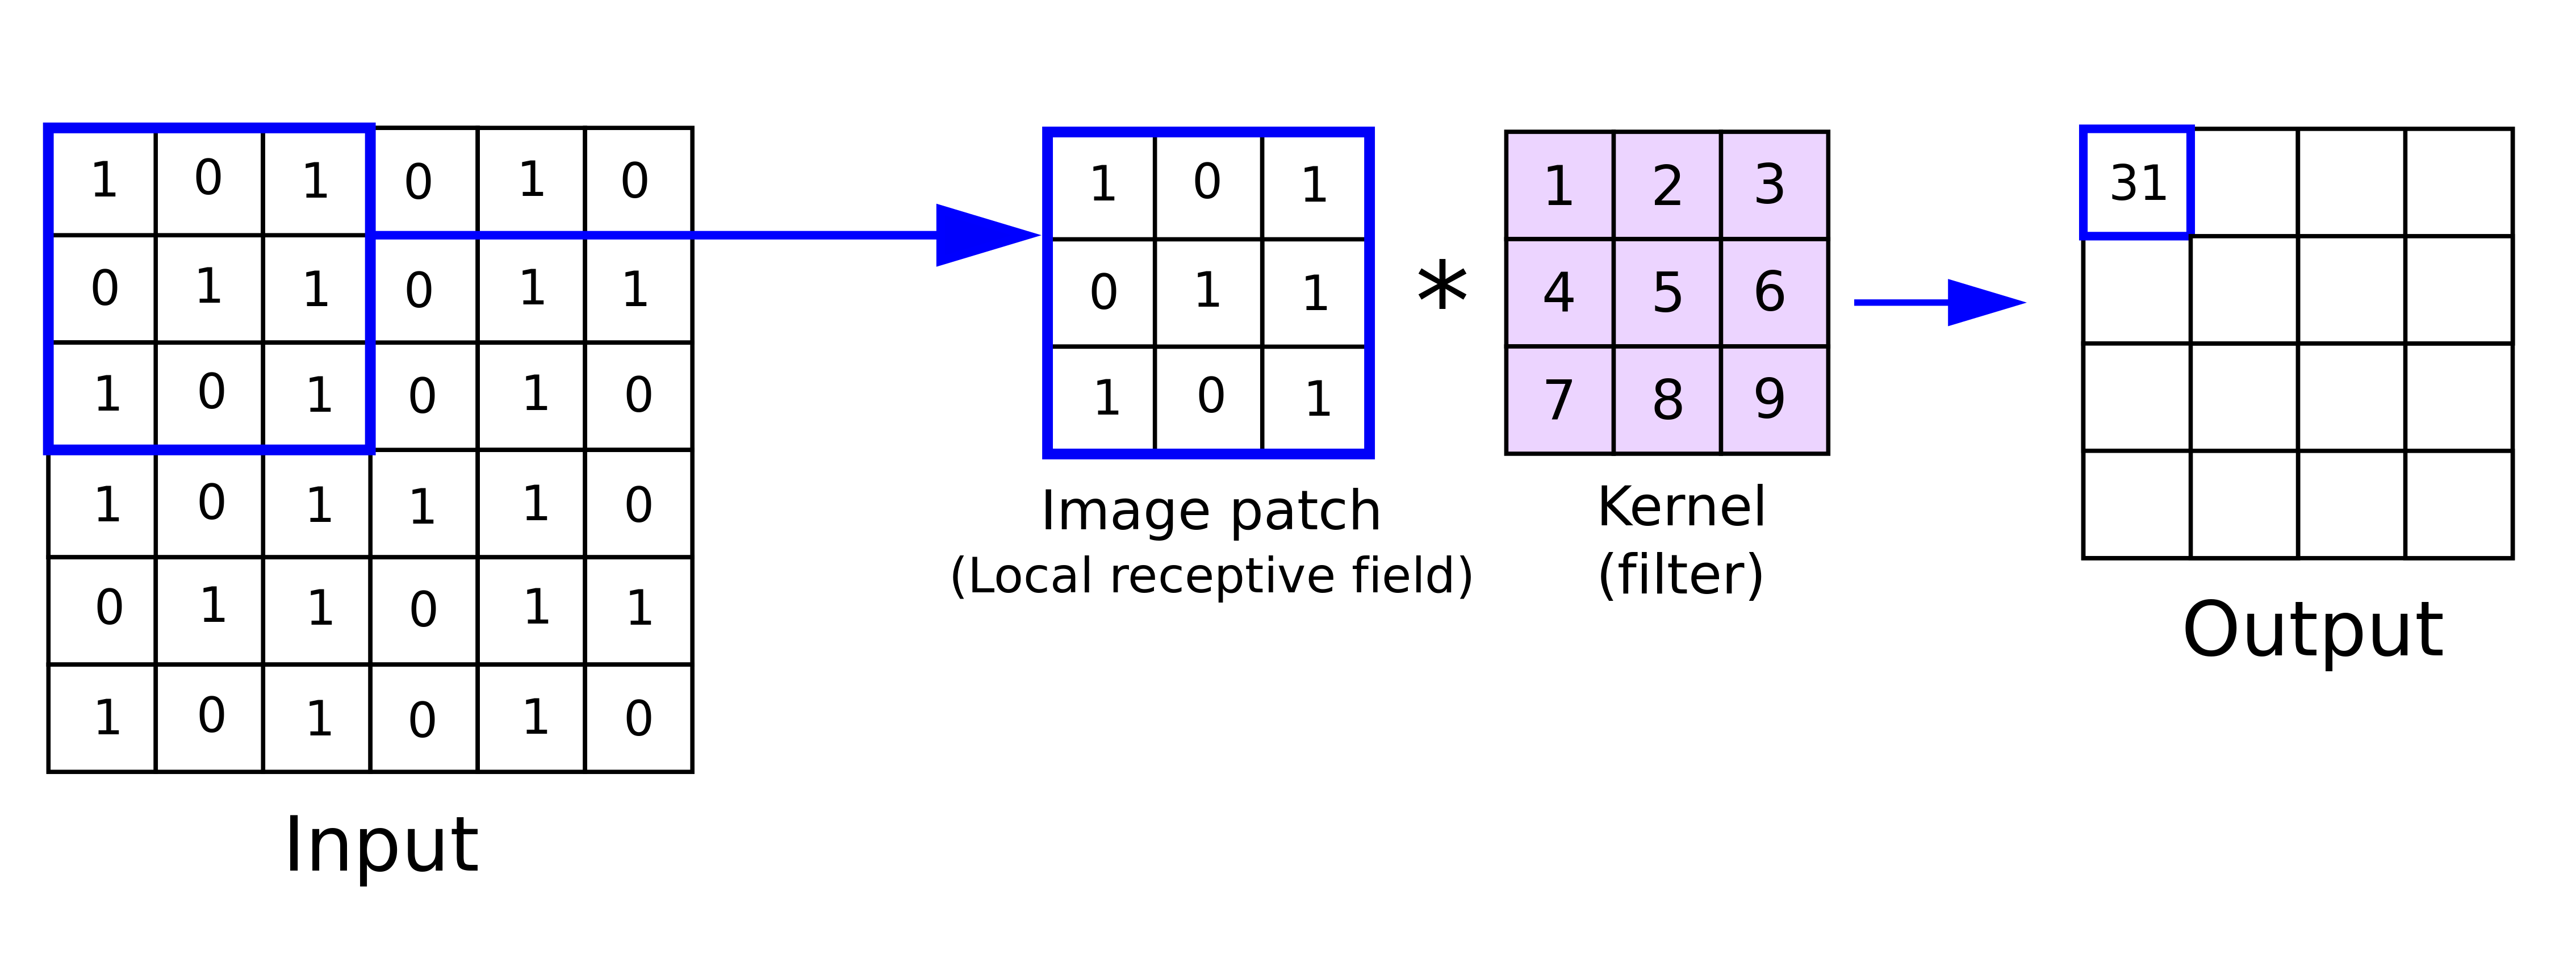


Let us consider an image patch $\mathbf{I}$ as a matrix and a kernel $\mathbf{K}$ of the same dimension $N \times N$, the output of the convolution operation is given by $S$ where,

$$
S = \sum^{N}_{i=1} \sum^{N}_{j=1} \mathbf{I}_{ij} \mathbf{K}_{ij} 
$$

We can verify this for the example above by showing that the defined kernel yields $S = 31$. It should be mentioned that all industry implementations of convolutional layers perform the **cross-correlation** operation and NOT the formal convolution operation. This is also true of our example. The difference between the cross-correlation and convolution operation in the context of CNNs is the orientation of the kernel. If we had taken a convolution rather than a cross-correlation for our example, technically we would have computed, 

$$
S = \sum^{N}_{i=1} \sum^{N}_{j=1} \mathbf{I}_{ij} \mathbf{K}_{N-i+1, n-j+1}
$$

where we have rotated the kernel by 180°. In DL, this distinction is irrelevant and the industry standard is to implement the cross-correlation operation since it is more efficient (it does require flipping the kernel). So far, we have only considered a single operation between the image and the kernel. However, in the sliding-window process many such operations are performed. Each time the operation is performed, the output is mapped to another image called the **feature map**. Let $\mathbf{S}$ be the feature map produced from $\mathbf{I} \star \mathbf{K}$ where $\star$ denotes the cross-correlation operation. $\mathbf{S}$ is given by, 

$$
S_{n, m} = \sum^{N}_{i=1} \sum^{N}_{j=1} \mathbf{I}_{n + i, m + j} \mathbf{K}_{ij} 
$$

### 0.2 Pooling Layers

### 0.3 The Structure of a CNN

We can think of the structure of a CNN as an MLP with additional convolutional layers. A typical CNN consists of an input layer followed by a sequential series of convolutional layers paired with proceeding pooling layers, which are then appended by an MLP. See the diagram below for reference,

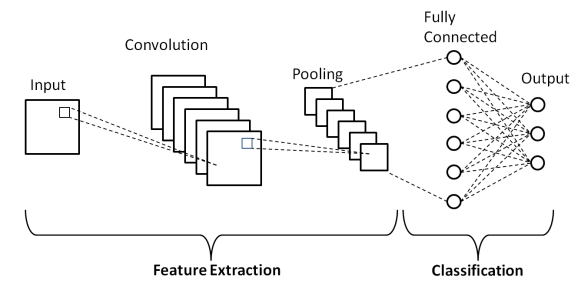

The convolutional layers perform feature extraction on the input image. They are followed by pooling layers which reduce the spatial size of feature maps while maintaining as much information as possible. This structure reduces the image into a lower dimensional representations. As the feature maps pass sequentially through the architecture, the network shifts from extracting fine-grained textures in the early layers to progressively more high-level, abstract features in the deeper layers. Eventually, these feature maps are flattened and concatenated into a high dimensional vector, the latent representation, which is fed into the MLP for classification or regression. The fully connected layers of the MLP often include a dropout mechanism during the training phase as a regularisation technique to reduce overfitting. Compared to MLP only models, there are two clear reasons why CNNs would be preferred,

**(a).** By using shared weights and pooling, CNNs significantly reduce the number of trainable parameters compared to a fully connected MLPs. This lowers the computational burden and minimises the risk of overfitting by focusing only on the most critical features.

**(b).** Unlike MLPs, which lose pixel relationships upon flattening, CNNs preserve the spatial structure of an image. This allows the network to recognise visual patterns and objects regardless of their location in the frame (translation invariance).

**LeNet-5:** The first well-known CNN with practical applications was Yann LeCun's LeNet-5, which was designed to recognise hand-written characters on bank checks. During the time of the paper, digit recognition models used heuristic rules for feature extraction. Using these rules, images would be turned into their latent representation and fed into a classifier. Determining these rules was a daunting task. LeCun demonstrated that using CNN layers for feature extraction would remove the need for creating ad hoc feature extraction rules. Instead, the kernels of the convolutional layers responsible for feature extraction could be determined via backpropagation without the need for human design choices.

### References

https://anhreynolds.com/blogs/cnn.html

https://towardsdatascience.com/the-math-behind-convolutional-neural-networks-6aed775df076/#:~:text=This%20equation%20tells%20us%20that,the%20kernel%20is%20currently%20positioned.

https://www.researchgate.net/figure/Basic-structure-of-Convolutional-Neural-Network-CNN-23-Artificial-neural-network_fig1_353049916

http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf